# Exploratory Data Analysis – MovieLens 100K Dataset
This notebook analyses the dataset used across all 4 collaborative filtering algorithms.
- Dataset: MovieLens 100K (https://grouplens.org/datasets/movielens/100k/)
- 100,000 ratings from 943 users on 1,682 movies

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

### 2. Load Dataset

In [2]:
DATASET_PATH = "datasets/ml-100k/"

# Ratings
ratings_df = pd.read_csv(
    DATASET_PATH + "u.data",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"]
)

# Movies
movies_df = pd.read_csv(
    DATASET_PATH + "u.item",
    sep="|",
    header=None,
    encoding="latin-1",
    names=[
        "movie_id", "title", "release_date", "video_release_date",
        "IMDb_URL", "unknown", "Action", "Adventure", "Animation",
        "Children's", "Comedy", "Crime", "Documentary", "Drama", "Fantasy",
        "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
        "Thriller", "War", "Western"
    ]
)

# Users
users_df = pd.read_csv(
    DATASET_PATH + "u.user",
    sep="|",
    header=None,
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

# Convert timestamp to datetime
ratings_df["datetime"] = pd.to_datetime(ratings_df["timestamp"], unit="s")

print(f"Ratings : {ratings_df.shape[0]:,} rows × {ratings_df.shape[1]} cols")
print(f"Movies  : {movies_df.shape[0]:,} rows × {movies_df.shape[1]} cols")
print(f"Users   : {users_df.shape[0]:,} rows × {users_df.shape[1]} cols")

Ratings : 100,000 rows × 5 cols
Movies  : 1,682 rows × 24 cols
Users   : 943 rows × 5 cols


### 3. Basic Dataset Statistics

In [3]:
n_users   = ratings_df["user_id"].nunique()
n_movies  = ratings_df["movie_id"].nunique()
n_ratings = len(ratings_df)
sparsity  = 1 - (n_ratings / (n_users * n_movies))

print(f"  Total Ratings     : {n_ratings:,}")
print(f"  Unique Users      : {n_users:,}")
print(f"  Unique Movies     : {n_movies:,}")
print(f"  Rating Scale      : {ratings_df['rating'].min()} – {ratings_df['rating'].max()}")
print(f"  Average Rating    : {ratings_df['rating'].mean():.4f}")
print(f"  Matrix Sparsity   : {sparsity * 100:.2f}%")
print(f"  Date Range        : {ratings_df['datetime'].min().date()} to {ratings_df['datetime'].max().date()}")

  Total Ratings     : 100,000
  Unique Users      : 943
  Unique Movies     : 1,682
  Rating Scale      : 1 – 5
  Average Rating    : 3.5299
  Matrix Sparsity   : 93.70%
  Date Range        : 1997-09-20 to 1998-04-22


### 4. Rating Distribution

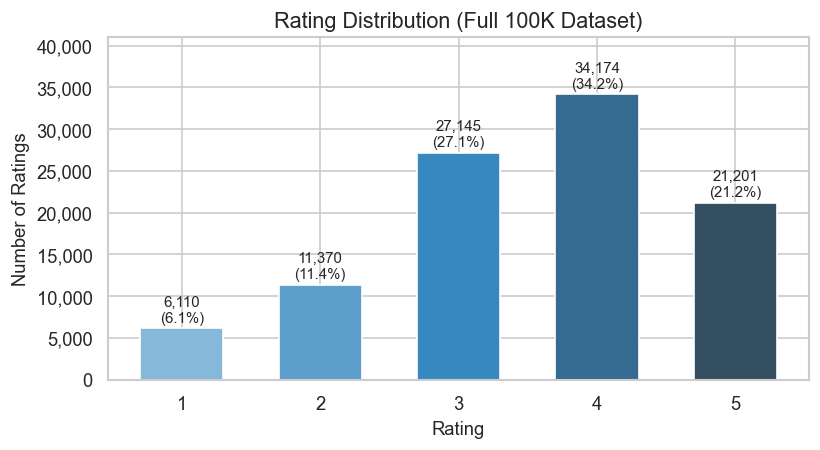

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

rating_counts = ratings_df["rating"].value_counts().sort_index()
bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=sns.color_palette("Blues_d", 5),
    edgecolor="white",
    width=0.6
)

for bar, count in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f"{count:,}\n({count/n_ratings*100:.1f}%)",
        ha="center", va="bottom", fontsize=9
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
ax.set_title("Rating Distribution (Full 100K Dataset)")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, max(rating_counts.values) * 1.20)   # ← adds headroom above tallest bar
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

### 5. Ratings per User Distribution

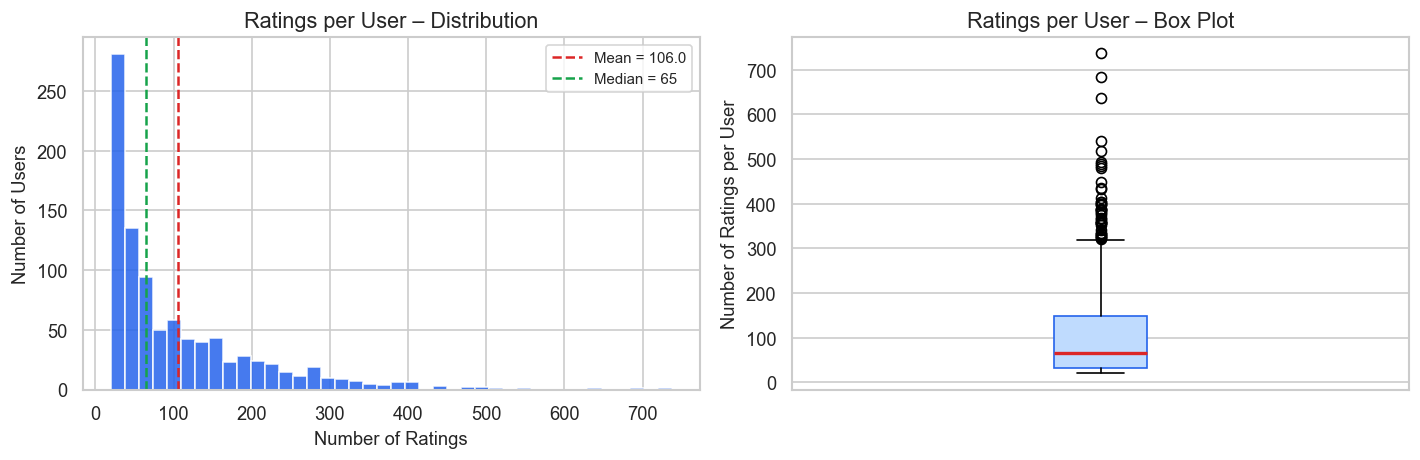

Min ratings per user  : 20
Max ratings per user  : 737
Mean ratings per user : 106.0
Median                : 65


In [5]:
ratings_per_user = ratings_df.groupby("user_id")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(ratings_per_user, bins=40, color="#2563EB", edgecolor="white", alpha=0.85)
axes[0].axvline(ratings_per_user.mean(), color="#DC2626", linestyle="--", linewidth=1.5, label=f"Mean = {ratings_per_user.mean():.1f}")
axes[0].axvline(ratings_per_user.median(), color="#16A34A", linestyle="--", linewidth=1.5, label=f"Median = {ratings_per_user.median():.0f}")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Ratings per User – Distribution")
axes[0].legend(fontsize=9)

# Box plot
axes[1].boxplot(ratings_per_user, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#BFDBFE", color="#2563EB"),
                medianprops=dict(color="#DC2626", linewidth=2))
axes[1].set_ylabel("Number of Ratings per User")
axes[1].set_title("Ratings per User – Box Plot")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Min ratings per user  : {ratings_per_user.min()}")
print(f"Max ratings per user  : {ratings_per_user.max()}")
print(f"Mean ratings per user : {ratings_per_user.mean():.1f}")
print(f"Median                : {ratings_per_user.median():.0f}")

### 6. Ratings per Movie Distribution

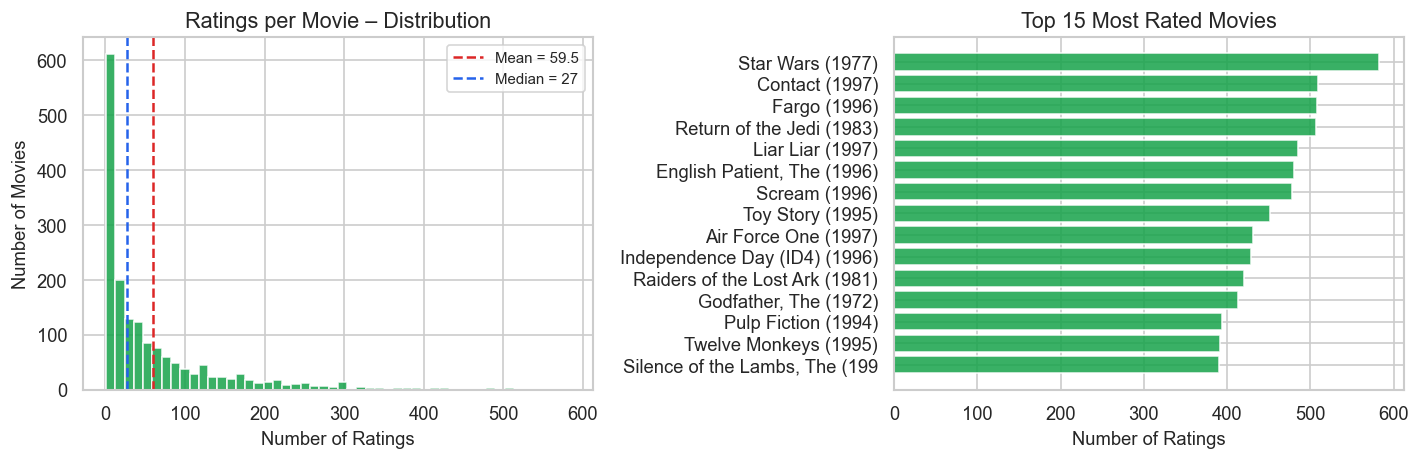

Min ratings per movie  : 1
Max ratings per movie  : 583
Mean ratings per movie : 59.5
Movies with < 10 ratings: 530 (31.5%)


In [6]:
ratings_per_movie = ratings_df.groupby("movie_id")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(ratings_per_movie, bins=50, color="#16A34A", edgecolor="white", alpha=0.85)
axes[0].axvline(ratings_per_movie.mean(), color="#DC2626", linestyle="--", linewidth=1.5, label=f"Mean = {ratings_per_movie.mean():.1f}")
axes[0].axvline(ratings_per_movie.median(), color="#2563EB", linestyle="--", linewidth=1.5, label=f"Median = {ratings_per_movie.median():.0f}")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Ratings per Movie – Distribution")
axes[0].legend(fontsize=9)

# Top 15 most rated movies
top15 = ratings_per_movie.sort_values(ascending=False).head(15)
top15_titles = movies_df.set_index("movie_id").loc[top15.index, "title"].str[:30]
axes[1].barh(top15_titles[::-1], top15.values[::-1], color="#16A34A", alpha=0.85)
axes[1].set_xlabel("Number of Ratings")
axes[1].set_title("Top 15 Most Rated Movies")

plt.tight_layout()
plt.show()

print(f"Min ratings per movie  : {ratings_per_movie.min()}")
print(f"Max ratings per movie  : {ratings_per_movie.max()}")
print(f"Mean ratings per movie : {ratings_per_movie.mean():.1f}")
print(f"Movies with < 10 ratings: {(ratings_per_movie < 10).sum()} ({(ratings_per_movie < 10).mean()*100:.1f}%)")

### 7. User-Item Matrix Sparsity Heatmap
Visualises a 50×50 sample of the full user-item matrix to show how sparse the data is.

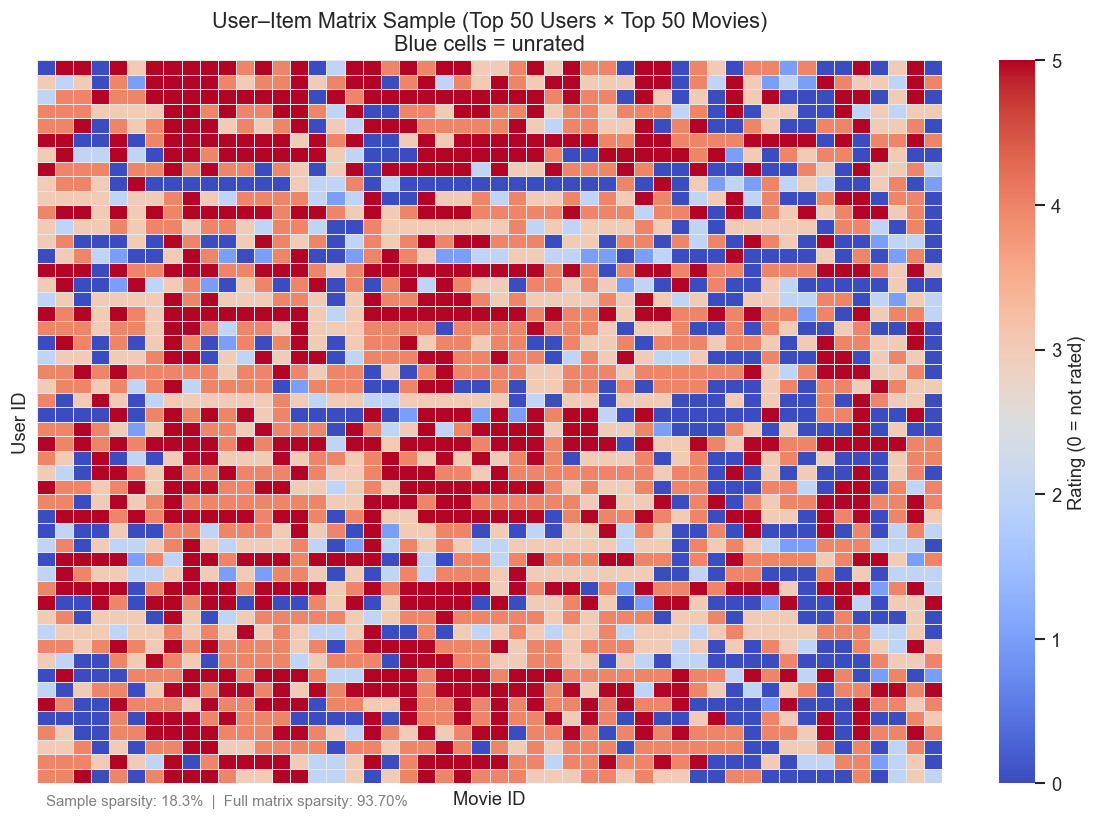

In [7]:
# Sample 50 most active users and 50 most rated movies
top50_users  = ratings_per_user.sort_values(ascending=False).head(50).index
top50_movies = ratings_per_movie.sort_values(ascending=False).head(50).index

sample_df = ratings_df[
    ratings_df["user_id"].isin(top50_users) &
    ratings_df["movie_id"].isin(top50_movies)
]

sample_matrix = sample_df.pivot_table(
    index="user_id", columns="movie_id", values="rating"
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    sample_matrix,
    ax=ax,
    cmap="coolwarm",
    linewidths=0.3,
    linecolor="#e5e7eb",
    cbar_kws={"label": "Rating (0 = not rated)"},
    xticklabels=False,
    yticklabels=False
)
ax.set_title("User–Item Matrix Sample (Top 50 Users × Top 50 Movies)\nBlue cells = unrated")
ax.set_xlabel("Movie ID")
ax.set_ylabel("User ID")

# Annotate sparsity
sample_sparsity = (sample_matrix == 0).values.sum() / sample_matrix.size
ax.text(0.01, -0.03, f"Sample sparsity: {sample_sparsity*100:.1f}%  |  Full matrix sparsity: {sparsity*100:.2f}%",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()

### 8. Ratings Over Time

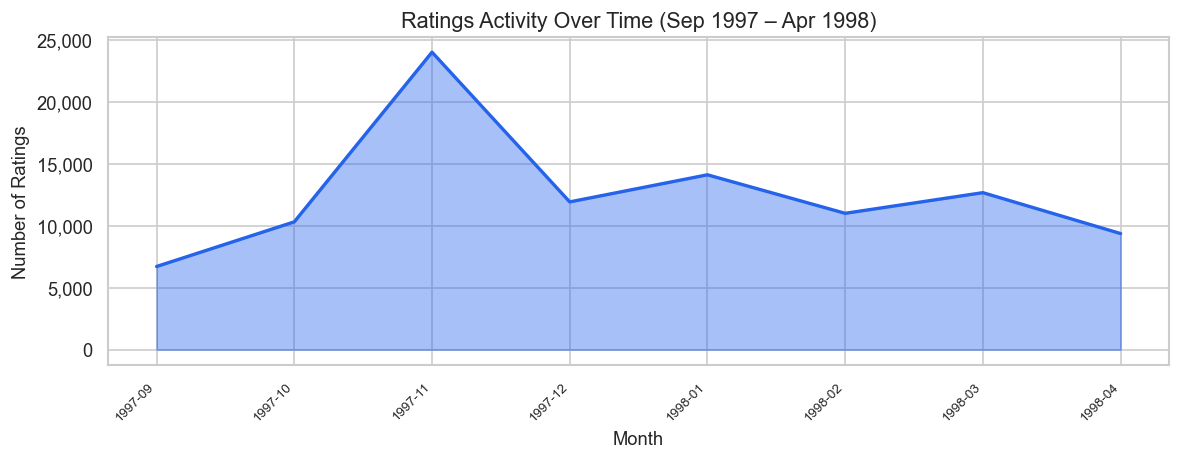

In [8]:
ratings_df["month"] = ratings_df["datetime"].dt.to_period("M")
monthly_counts = ratings_df.groupby("month").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    range(len(monthly_counts)),
    monthly_counts.values,
    alpha=0.4, color="#2563EB"
)
ax.plot(range(len(monthly_counts)), monthly_counts.values, color="#2563EB", linewidth=2)
ax.set_xticks(range(len(monthly_counts)))
ax.set_xticklabels([str(p) for p in monthly_counts.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Ratings")
ax.set_title("Ratings Activity Over Time (Sep 1997 – Apr 1998)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### 9. Genre Distribution

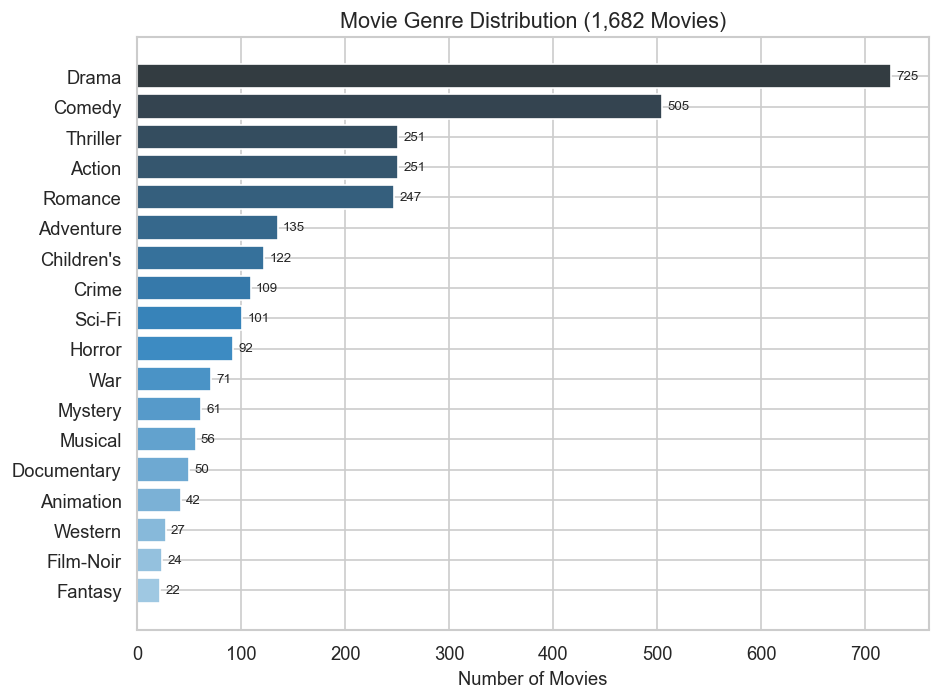

In [9]:
genre_cols = [
    "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
    "Thriller", "War", "Western"
]

genre_counts = movies_df[genre_cols].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(
    genre_counts.index, genre_counts.values,
    color=sns.color_palette("Blues_d", len(genre_counts)),
    edgecolor="white"
)

for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)

ax.set_xlabel("Number of Movies")
ax.set_title("Movie Genre Distribution (1,682 Movies)")
plt.tight_layout()
plt.show()

### 10. User Demographics

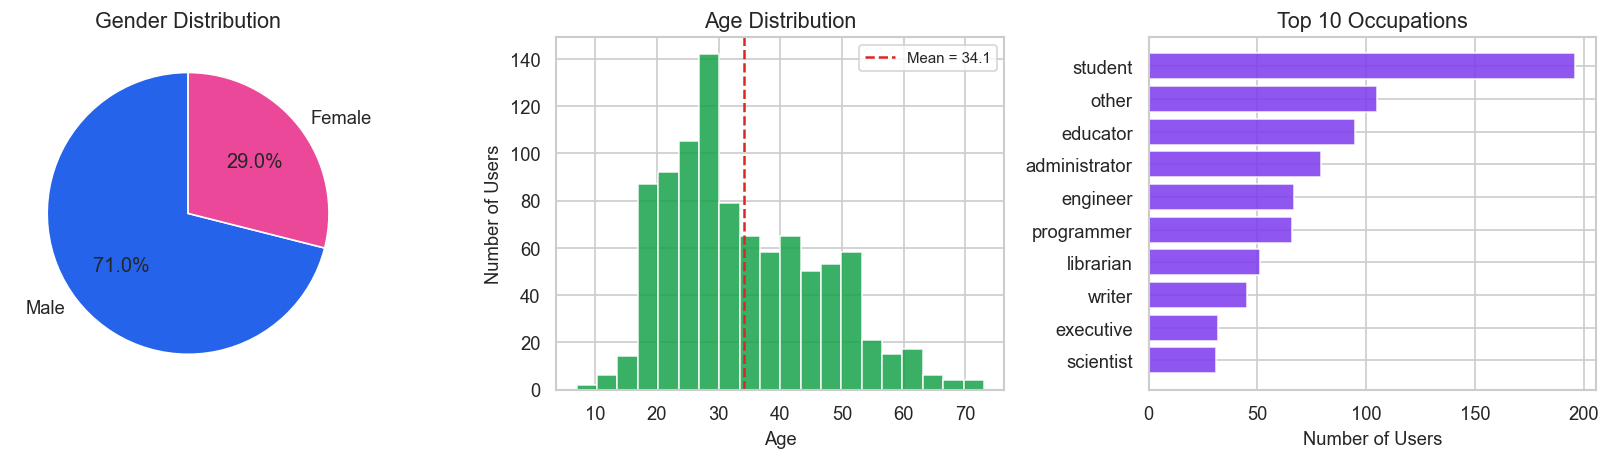

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gender
gender_counts = users_df["gender"].value_counts()
axes[0].pie(
    gender_counts.values,
    labels=["Male", "Female"],
    autopct="%1.1f%%",
    colors=["#2563EB", "#EC4899"],
    startangle=90
)
axes[0].set_title("Gender Distribution")

# Age
axes[1].hist(users_df["age"], bins=20, color="#16A34A", edgecolor="white", alpha=0.85)
axes[1].axvline(users_df["age"].mean(), color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Mean = {users_df['age'].mean():.1f}")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Age Distribution")
axes[1].legend(fontsize=9)

# Top 10 occupations
top_occ = users_df["occupation"].value_counts().head(10)
axes[2].barh(top_occ.index[::-1], top_occ.values[::-1], color="#7C3AED", alpha=0.85)
axes[2].set_xlabel("Number of Users")
axes[2].set_title("Top 10 Occupations")

plt.tight_layout()
plt.show()

### 11. Dataset Size Experiment Overview
Shows how user and movie coverage changes across the 6 experiment sizes.

Dataset characteristics per experiment size:


,Size,Users,Movies,Avg Rating,Sparsity %
0,10000,385,1254,3.559,97.93
1,20000,459,1410,3.536,96.91
2,40000,653,1549,3.540,96.05
3,60000,874,1617,3.535,95.75
4,80000,943,1650,3.532,94.86
5,100000,943,1682,3.530,93.70


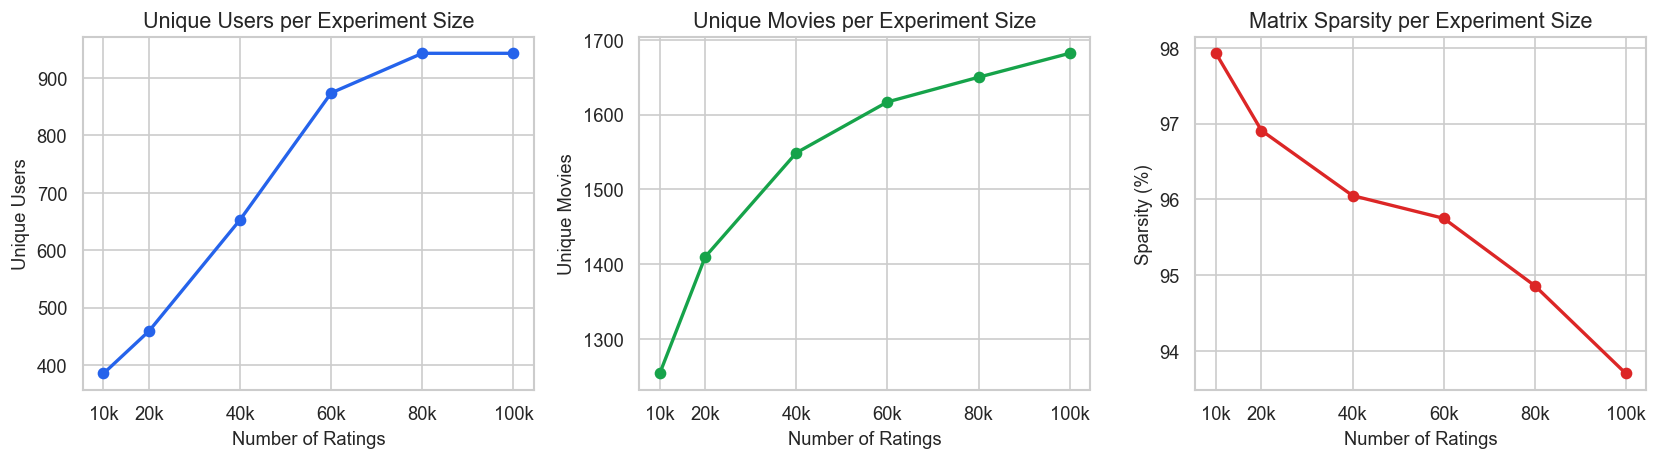

In [11]:
sizes = [10000, 20000, 40000, 60000, 80000, 100000]
size_stats = []

for s in sizes:
    subset = ratings_df.head(s)
    size_stats.append({
        "Size": s,
        "Users": subset["user_id"].nunique(),
        "Movies": subset["movie_id"].nunique(),
        "Avg Rating": round(subset["rating"].mean(), 3),
        "Sparsity %": round(
            (1 - s / (subset["user_id"].nunique() * subset["movie_id"].nunique())) * 100, 2
        )
    })

size_df = pd.DataFrame(size_stats)
print("Dataset characteristics per experiment size:")
display(size_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(size_df["Size"], size_df["Users"], marker="o", color="#2563EB", linewidth=2)
axes[0].set_title("Unique Users per Experiment Size")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Unique Users")
axes[0].set_xticks(sizes)
axes[0].set_xticklabels([f"{s//1000}k" for s in sizes])

axes[1].plot(size_df["Size"], size_df["Movies"], marker="o", color="#16A34A", linewidth=2)
axes[1].set_title("Unique Movies per Experiment Size")
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Unique Movies")
axes[1].set_xticks(sizes)
axes[1].set_xticklabels([f"{s//1000}k" for s in sizes])

axes[2].plot(size_df["Size"], size_df["Sparsity %"], marker="o", color="#DC2626", linewidth=2)
axes[2].set_title("Matrix Sparsity per Experiment Size")
axes[2].set_xlabel("Number of Ratings")
axes[2].set_ylabel("Sparsity (%)")
axes[2].set_xticks(sizes)
axes[2].set_xticklabels([f"{s//1000}k" for s in sizes])

plt.tight_layout()
plt.show()